In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score



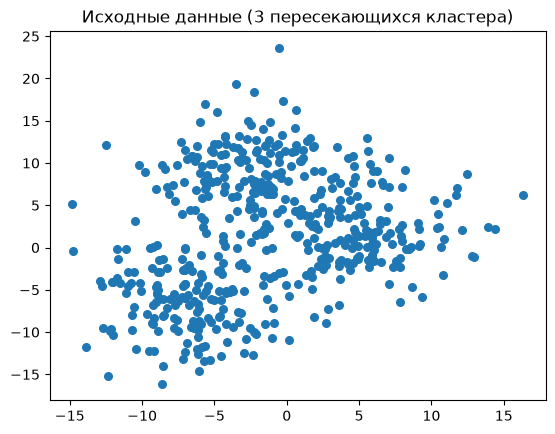

In [10]:
# Генерируем пересекающиеся кластеры
X, y = make_blobs(n_samples=500, centers=3, cluster_std=3.8, random_state=42)

# Визуализация
plt.scatter(X[:, 0], X[:, 1], s=30)
plt.title("Исходные данные (3 пересекающихся кластера)")
plt.show()

In [11]:
K_range = range(2, 9)
inertias = []
silhouettes = []
calinski_harabasz = []
davies_bouldin = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    print(labels[:10])
    inertias.append(kmeans.inertia_)
    print(kmeans.inertia_)
    silhouettes.append(silhouette_score(X, labels))
    calinski_harabasz.append(calinski_harabasz_score(X, labels))
    davies_bouldin.append(davies_bouldin_score(X, labels))
    print(silhouette_score(X, labels))

[1 0 0 0 0 0 1 0 0 1]
21880.15214834526
0.4682200749493246
[1 2 0 2 0 0 0 0 0 1]
12289.847374730827
0.4830885634890487
[3 0 2 0 2 2 3 2 2 3]
10393.062264699918
0.40650218621429024
[1 3 2 0 2 4 4 2 4 3]
8789.065276319738
0.3625384720078604
[1 2 3 2 3 3 3 3 3 4]
7415.705771187641
0.34229397100506054
[1 2 4 2 4 4 5 4 5 0]
6328.570079540571
0.3414066444973279
[6 0 5 0 5 5 6 5 0 1]
5593.858834383004
0.35483110961302894


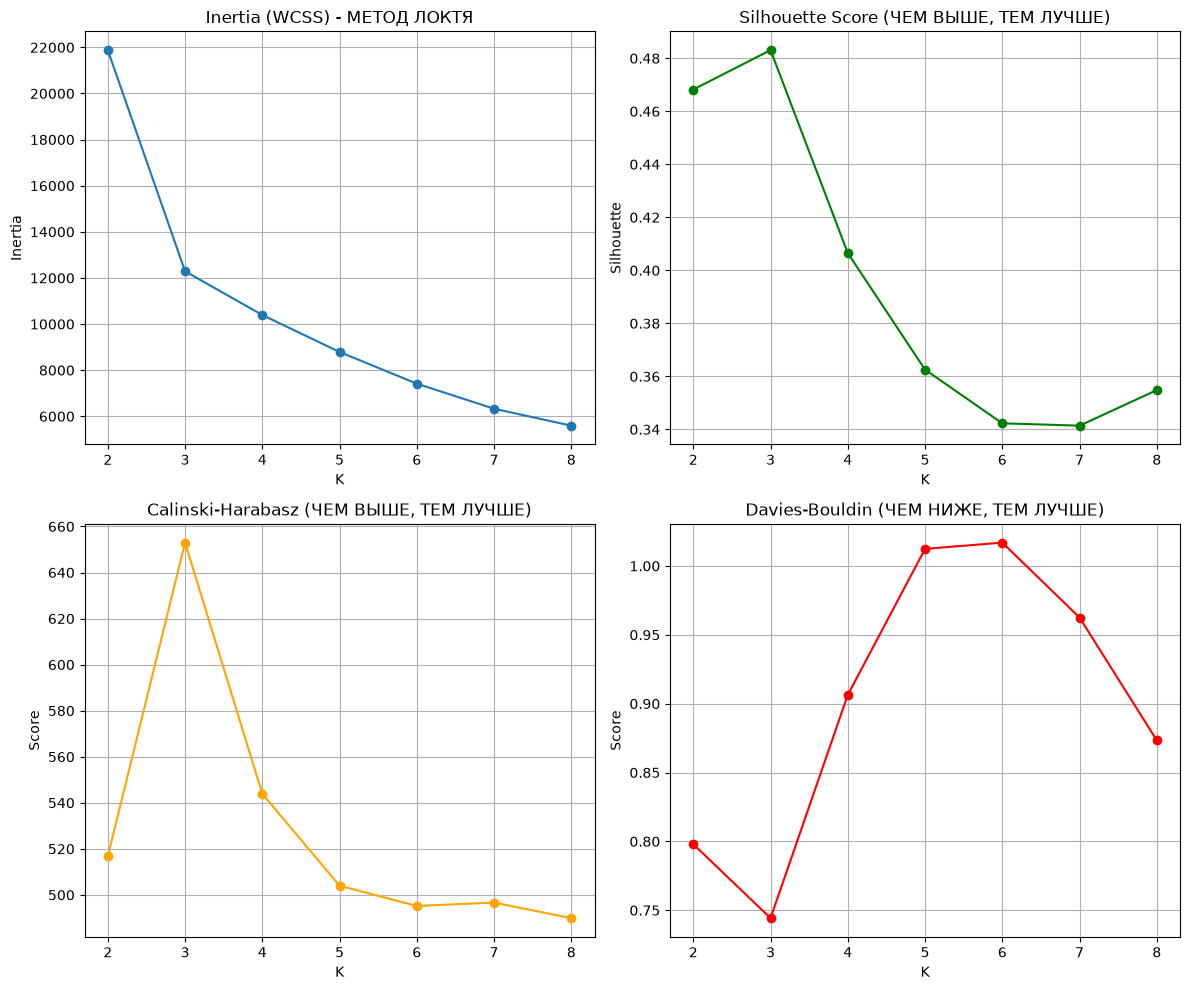

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Inertia (метод локтя)
axes[0, 0].plot(K_range, inertias, marker='o')
axes[0, 0].set_title('Inertia (WCSS) - МЕТОД ЛОКТЯ')
axes[0, 0].set_xlabel('K')
axes[0, 0].set_ylabel('Inertia')
axes[0, 0].grid(True)

# 2. Silhouette Score
axes[0, 1].plot(K_range, silhouettes, marker='o', color='green')
axes[0, 1].set_title('Silhouette Score (ЧЕМ ВЫШЕ, ТЕМ ЛУЧШЕ)')
axes[0, 1].set_xlabel('K')
axes[0, 1].set_ylabel('Silhouette')
axes[0, 1].grid(True)

# 3. Calinski-Harabasz
axes[1, 0].plot(K_range, calinski_harabasz, marker='o', color='orange')
axes[1, 0].set_title('Calinski-Harabasz (ЧЕМ ВЫШЕ, ТЕМ ЛУЧШЕ)')
axes[1, 0].set_xlabel('K')
axes[1, 0].set_ylabel('Score')
axes[1, 0].grid(True)

# 4. Davies-Bouldin
axes[1, 1].plot(K_range, davies_bouldin, marker='o', color='red')
axes[1, 1].set_title('Davies-Bouldin (ЧЕМ НИЖЕ, ТЕМ ЛУЧШЕ)')
axes[1, 1].set_xlabel('K')
axes[1, 1].set_ylabel('Score')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [21]:
def cnt_subs(s):
    cnt_letters = {}
    answer = 0

    for char in s:
        cnt_letters[char] = cnt_letters.get(char,0) +  1

    for cnt in cnt_letters.values():
        answer += cnt *(cnt+1)//2

    return answer

def solve():
    s = input()
    print(cnt_subs(s))

solve()

5


In [18]:
def build_permutation(n,k):
    result = []

    for num in range(n,0,-1):
        position = min(k,len(result))

        result.insert(position,num)
        k-=position
    return result

def solve():
    n,k = map(int,input().split())
    permutation = build_permutation(n,k)
    print(' '.join(map(str,permutation)))

solve()

1 2 3 4 5 6 10 9 7 8


In [ ]:
def build_permutation(n,k):
    result = []

    for num in range(n,0,-1):
        position = min(k,len(result))

        result.insert(position,num)
        k-=pos
    return result

def solve():
    n,k = map(int,input().split())
    permutation = build_permutation(n,k)
    print(''.join(map(str,permutation)))

solve()

In [22]:
def cnt_trees(n,m,x,forest):
    grid = [
        [1 if forest[i][j] == '*' else 0 for j in range(m)] for i in range(n)
    ]

    row_pref = [
        [0] * (m+1) for _ in range(n)
    ]
    for i in range(n):
        for j in range(m):
            row_pref[i][j+1] = row_pref[i][j] + grid[i][j]


    cnt = 0
    max_side = min(n,m)

    for side in range(1,max_side + 1):
        col_sum = [0] * n
        for i in range(n):
            if i < side:
                col_sum[i] = row_pref[i][side] - row_pref[i][0]
            else:
                col_sum[i] = 0
        
        cur_sum = sum(col_sum[:side])
        if cur_sum == x: cnt+=1

        for i in range(1,n-side+1):
            cur_sum = cur_sum - sum(col_sum[i-1:i-1+side]) + sum(col_sum[i:i+side])
            if cur_sum == x: cnt+=1

        for j in range(1, m-side+1):
            for i in range(n):
                col_sum[i] = row_pref[i][j+side] - row_pref[i][j]
            
            cur_sum = sum(col_sum[:side])
            if cur_sum == x: cnt+=1

            for i in range(1,n-side+1):
                cur_sum = cur_sum - sum(col_sum[i-1:i-1+side]) + sum(col_sum[i:i+side])
                if cur_sum == x: cnt+=1
    
    return cnt

def solve():
    n,m,x = map(int,input().split())

    forest = []
    for _ in range(n):
        forest.append(input().strip())

    print(cnt_trees(n,m,x,forest))

solve()

3


In [23]:
def posl_val():
    n = int(input())

    cache = {}
    cache[0] = 0
    cache[1] = 1
    
    def calc(val):
        if val in cache:
            return cache[val]
        
        res = 0
        i = 2

        while i<=val:
            current = val // i
            last = val//current
            res += calc(current) * (last-i+1)
            i = last+1
        cache[val] = res
        return res
    return calc(n)

posl_val()


13

In [24]:
def posl_val():
    n = int(input())

    cache = {}
    cache[0] = 0
    cache[1] = 1
    
    def calc(val):
        if val in cache:
            return cache[val]
        
        res = 0
        i = 2

        while i<=val:
            current = val // i
            last = val//current
            res += calc(current) * (last-i+1)
            i = last+1
        cache[val] = res
        return res
    return calc(n)

posl_val()

13